In [1]:
from mftool import Mftool
import pandas as pd
import yfinance as yf
from datetime import datetime
import os

print("All tools loaded successfully!")

All tools loaded successfully!


In [2]:
mf = Mftool()
all_schemes = mf.get_scheme_codes()
print(f"Total funds available: {len(all_schemes)}")
print("\nFirst 5 funds:")
for code, name in list(all_schemes.items())[:5]:
    print(f"  Code: {code}  |  Name: {name}")

Total funds available: 14367

First 5 funds:
  Code: Scheme Code  |  Name: Scheme Name
  Code: 119551  |  Name: Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW
  Code: 119552  |  Name: Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - MONTHLY IDCW
  Code: 119553  |  Name: Aditya Birla Sun Life Banking & PSU Debt Fund  - Direct - Quarterly IDCW
  Code: 108272  |  Name: Aditya Birla Sun Life Banking & PSU Debt Fund  - REGULAR - IDCW


In [3]:
fund_code = "119533"  # HDFC Mid-Cap Opportunities Fund
nav_data = mf.get_scheme_historical_nav(fund_code, as_Dataframe=True)
print(f"Fund data shape: {nav_data.shape}")
print(f"Columns: {nav_data.columns.tolist()}")
print("\nLatest 5 entries:")
print(nav_data.head())

Fund data shape: (3226, 2)
Columns: ['nav', 'dayChange']

Latest 5 entries:
                  nav  dayChange
date                            
15-05-2026  118.65230    -0.2327
14-05-2026  118.88500     0.0281
13-05-2026  118.85690    -0.0177
12-05-2026  118.87460    -0.0848
11-05-2026  118.95940    -0.1527


In [4]:
# Reset the index so 'date' becomes a proper column
nav_data = nav_data.reset_index()

# Rename columns to make them cleaner
nav_data.columns = ['date', 'nav', 'day_change']

# Convert date from text to actual date format Python understands
nav_data['date'] = pd.to_datetime(nav_data['date'], format='%d-%m-%Y')

# Convert nav to a number (it comes as text from mftool)
nav_data['nav'] = pd.to_numeric(nav_data['nav'], errors='coerce')

# Sort oldest to newest (AMFI gives newest first)
nav_data = nav_data.sort_values('date').reset_index(drop=True)

# Add fund name and code as columns
nav_data['fund_code'] = '119533'
nav_data['fund_name'] = 'HDFC Mid-Cap Opportunities Fund'

# Save to your data folder
os.makedirs('../data', exist_ok=True)
nav_data.to_csv('../data/hdfc_midcap_nav.csv', index=False)

print("Saved successfully!")
print(f"Date range: {nav_data['date'].min()} to {nav_data['date'].max()}")
print(f"Total rows: {len(nav_data)}")
print("\nFirst 5 rows (oldest):")
print(nav_data.head())

Saved successfully!
Date range: 2013-01-02 00:00:00 to 2026-05-15 00:00:00
Total rows: 3226

First 5 rows (oldest):
        date      nav  day_change fund_code                        fund_name
0 2013-01-02  42.5243         NaN    119533  HDFC Mid-Cap Opportunities Fund
1 2013-01-03  42.5392      0.0149    119533  HDFC Mid-Cap Opportunities Fund
2 2013-01-04  42.5567      0.0175    119533  HDFC Mid-Cap Opportunities Fund
3 2013-01-07  42.6007      0.0440    119533  HDFC Mid-Cap Opportunities Fund
4 2013-01-08  42.6146      0.0139    119533  HDFC Mid-Cap Opportunities Fund


In [5]:
# Pick the start and end NAV
start_nav = nav_data['nav'].iloc[0]   # First ever NAV (2013)
end_nav = nav_data['nav'].iloc[-1]    # Latest NAV (today)
# Calculate number of years between first and last date
start_date = nav_data['date'].iloc[0]
end_date = nav_data['date'].iloc[-1]
num_years = (end_date - start_date).days / 365.25
# CAGR formula
cagr = (end_nav / start_nav) ** (1 / num_years) - 1
print(f"Start NAV  : ₹{start_nav:.2f}  ({start_date.date()})")
print(f"End NAV    : ₹{end_nav:.2f}  ({end_date.date()})")
print(f"Years      : {num_years:.1f}")
print(f"CAGR       : {cagr*100:.2f}%")
print(f"\nMeaning: ₹1,00,000 invested in 2013 is now worth ₹{100000 * (end_nav/start_nav):,.0f}")

Start NAV  : ₹42.52  (2013-01-02)
End NAV    : ₹118.65  (2026-05-15)
Years      : 13.4
CAGR       : 7.98%

Meaning: ₹1,00,000 invested in 2013 is now worth ₹279,022


In [6]:
# Calculate daily returns (% change from one day to next)
nav_data['daily_return'] = nav_data['nav'].pct_change()

# Volatility = how wildly returns swing (annualised)
volatility = nav_data['daily_return'].std() * (252 ** 0.5)

# Average annual return (simple version using daily returns)
avg_annual_return = nav_data['daily_return'].mean() * 252

# Risk free rate in India (91-day T-Bill approx)
risk_free_rate = 0.065

# Sharpe Ratio
sharpe = (avg_annual_return - risk_free_rate) / volatility

print(f"Average Annual Return : {avg_annual_return*100:.2f}%")
print(f"Volatility (Risk)     : {volatility*100:.2f}%")
print(f"Sharpe Ratio          : {sharpe:.2f}")
print()
if sharpe > 1:
    print("Verdict: GOOD fund — solid return for the risk taken")
elif sharpe > 0.5:
    print("Verdict: OKAY fund — decent but not exceptional")
else:
    print("Verdict: POOR — not enough return for the risk")

Average Annual Return : 8.03%
Volatility (Risk)     : 1.38%
Sharpe Ratio          : 1.11

Verdict: GOOD fund — solid return for the risk taken


In [8]:
# Calculate running maximum (peak NAV at any point in time)
nav_data['peak_nav'] = nav_data['nav'].cummax()

# Drawdown = how far below the peak are we on each day
nav_data['drawdown'] = (nav_data['nav'] - nav_data['peak_nav']) / nav_data['peak_nav']

# Max drawdown = the worst single drop
max_drawdown = nav_data['drawdown'].min()

# Find when that worst crash happened
worst_day = nav_data.loc[nav_data['drawdown'].idxmin(), 'date']

print(f"Max Drawdown : {max_drawdown*100:.2f}%")
print(f"Worst day    : {worst_day.date()}")
print()
print(f"Meaning: At its worst point, this fund fell {abs(max_drawdown)*100:.1f}%")
print(f"from its previous peak. This happened around {worst_day.strftime('%B %Y')}.")
print()

# Show top 5 worst drawdown periods
print("5 worst drawdown days:")
worst_5 = nav_data.nsmallest(5, 'drawdown')[['date', 'nav', 'peak_nav', 'drawdown']]
worst_5['drawdown_pct'] = worst_5['drawdown'] * 100
print(worst_5[['date', 'nav', 'peak_nav', 'drawdown_pct']].to_string(index=False))

Max Drawdown : -2.38%
Worst day    : 2020-03-24

Meaning: At its worst point, this fund fell 2.4%
from its previous peak. This happened around March 2020.

5 worst drawdown days:
      date     nav  peak_nav  drawdown_pct
2020-03-24 77.0866    78.964     -2.377539
2020-03-23 77.0986    78.964     -2.362342
2020-03-19 77.1792    78.964     -2.260271
2020-03-26 77.2117    78.964     -2.219113
2020-03-20 77.4867    78.964     -1.870853


In [9]:
def sip_calculator(monthly_amount, fund_nav_data, start_date, end_date):
    """
    Simulates a real SIP using actual historical NAV data.
    Invests a fixed amount on the 1st of every month.
    """
    # Filter data to our date range
    mask = (fund_nav_data['date'] >= start_date) & (fund_nav_data['date'] <= end_date)
    period_data = fund_nav_data[mask].copy()
    
    # Get first available NAV of each month (investment day)
    period_data['month'] = period_data['date'].dt.to_period('M')
    monthly_nav = period_data.groupby('month').first().reset_index()
    
    total_units = 0
    total_invested = 0
    investment_log = []
    
    for _, row in monthly_nav.iterrows():
        units_bought = monthly_amount / row['nav']
        total_units += units_bought
        total_invested += monthly_amount
        investment_log.append({
            'month': str(row['month']),
            'nav_at_purchase': round(row['nav'], 2),
            'units_bought': round(units_bought, 3),
            'total_units': round(total_units, 3),
            'total_invested': total_invested
        })
    
    # Final value = total units × latest NAV
    final_nav = fund_nav_data['nav'].iloc[-1]
    final_value = total_units * final_nav
    profit = final_value - total_invested
    returns_pct = (profit / total_invested) * 100
    
    return {
        'monthly_amount': monthly_amount,
        'total_invested': total_invested,
        'final_value': round(final_value, 2),
        'profit': round(profit, 2),
        'returns_pct': round(returns_pct, 2),
        'total_units': round(total_units, 3),
        'months': len(monthly_nav),
        'log': investment_log
    }

# Run it — ₹5,000/month SIP for 5 years
result = sip_calculator(
    monthly_amount=5000,
    fund_nav_data=nav_data,
    start_date=pd.Timestamp('2020-01-01'),
    end_date=pd.Timestamp('2025-01-01')
)

print("=" * 45)
print("       SIP SIMULATION RESULTS")
print("=" * 45)
print(f"Monthly SIP Amount  : ₹{result['monthly_amount']:,}")
print(f"Duration            : {result['months']} months")
print(f"Total Invested      : ₹{result['total_invested']:,}")
print(f"Current Value       : ₹{result['final_value']:,}")
print(f"Total Profit        : ₹{result['profit']:,}")
print(f"Total Returns       : {result['returns_pct']}%")
print(f"Total Units Held    : {result['total_units']}")
print("=" * 45)
print(f"\nFor every ₹1 invested, you got back ₹{result['final_value']/result['total_invested']:.2f}")

       SIP SIMULATION RESULTS
Monthly SIP Amount  : ₹5,000
Duration            : 61 months
Total Invested      : ₹305,000
Current Value       : ₹392,526.36
Total Profit        : ₹87,526.36
Total Returns       : 28.7%
Total Units Held    : 3308.207

For every ₹1 invested, you got back ₹1.29


In [17]:
mf = Mftool()

# Get all scheme codes — same as Cell 2 in your notebook
all_codes = mf.get_scheme_codes()

# Convert to a DataFrame (like a SQL table with two columns: code, fund_name)
schemes_df = pd.DataFrame(list(all_codes.items()), columns=['code', 'fund_name'])

print(f"Loaded {len(schemes_df)} schemes")

# ---- SEARCH FUNCTION ----
def search_fund(keyword):
    """Search for funds by keyword. Not case-sensitive."""
    keyword = keyword.lower()
    results = schemes_df[schemes_df['fund_name'].str.lower().str.contains(keyword)]
    print(f"\n--- Results for '{keyword}' ---")
    print(results.to_string(index=False))
    print(f"\nTotal matches: {len(results)}")
    return results

# Test it — search for "UTI Nifty"
search_fund("UTI Nifty 50 Index")

Loaded 14367 schemes

--- Results for 'uti nifty 50 index' ---
  code                                              fund_name
120717           UTI Nifty 50 Index Fund - Direct Plan - IDCW
120716        UTI Nifty 50 Index Fund - Growth Option- Direct
100822 UTI Nifty 50 Index Fund - Regular Plan - Growth Option
100823          UTI Nifty 50 Index Fund - Regular Plan - IDCW

Total matches: 4


,code,fund_name
8932,120717,UTI Nifty 50 Index Fund - Direct Plan - IDCW
8933,120716,UTI Nifty 50 Index Fund - Growth Option- Direct
8934,100822,UTI Nifty 50 Index Fund - Regular Plan - Growt...
8935,100823,UTI Nifty 50 Index Fund - Regular Plan - IDCW


In [29]:
# ============================================================
# CELL 9 — Fetch NAV data for 35 verified Indian mutual funds
# ============================================================
# 4 categories: Large Cap (6), Mid Cap (10), Small Cap (9),
# Index Fund (8). ELSS dropped due to data quality issues.
# All codes verified via AMFI search using mftool.
# ============================================================

import time

funds_by_category = {

    "Large Cap": {
        "118825": "Mirae Asset Large Cap Fund",
        "118632": "Nippon India Large Cap Fund",
        "118617": "Edelweiss Large Cap Fund",
        "118955": "HDFC Flexi Cap Fund",
        "122639": "Parag Parikh Flexi Cap Fund",
        "133839": "PGIM India Flexi Cap Fund",
    },

    "Mid Cap": {
        "119533": "HDFC Mid-Cap Opportunities Fund",
        "120505": "Axis Midcap Fund",
        "119071": "DSP Midcap Fund",
        "140228": "Edelweiss Mid Cap Fund",
        "127042": "Motilal Oswal Midcap Fund",
        "119581": "Sundaram Mid Cap Fund",
        "118668": "Nippon India Growth Mid Cap Fund",
        "120403": "Invesco India Midcap Fund",
        "120726": "UTI Mid Cap Fund",
        "120841": "Quant Mid Cap Fund",
    },

    "Small Cap": {
        "125497": "SBI Small Cap Fund",
        "118778": "Nippon India Small Cap Fund",
        "125354": "Axis Small Cap Fund",
        "130503": "HDFC Small Cap Fund",
        "119212": "DSP Small Cap Fund",
        "146130": "Canara Robeco Small Cap Fund",
        "120591": "ICICI Prudential Smallcap Fund",
        "145206": "Tata Small Cap Fund",
        "120828": "Quant Small Cap Fund",
    },

    "Index Fund": {
        "120716": "UTI Nifty 50 Index Fund",
        "119827": "SBI Nifty Index Fund",
        "120620": "ICICI Prudential Nifty 50 Index Fund",
        "147666": "Axis Nifty 100 Index Fund",
        "147622": "Motilal Oswal Nifty Midcap 150 Index Fund",
        "148726": "Nippon India Nifty Midcap 150 Index Fund",
        "141877": "DSP Nifty 50 Equal Weight Index Fund",
        "118741": "Nippon India Index Fund Nifty 50 Plan",
    },
}

all_dfs      = []
failed_funds = []
fetched      = 0

for category, funds in funds_by_category.items():
    print(f"\n📂 Category: {category}")
    print("-" * 45)

    for code, name in funds.items():
        try:
            raw_data = mf.get_scheme_historical_nav(code, as_json=False)

            if raw_data is None or 'data' not in raw_data:
                print(f"  ❌ {name} (code {code}) — no data")
                failed_funds.append((code, name, category))
                continue

            df = pd.DataFrame(raw_data['data'])
            if df.empty:
                print(f"  ❌ {name} (code {code}) — empty")
                failed_funds.append((code, name, category))
                continue

            df['date']      = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
            df['nav']       = pd.to_numeric(df['nav'], errors='coerce')
            df              = df.dropna(subset=['date', 'nav'])
            df              = df.sort_values('date').reset_index(drop=True)
            df['fund_code'] = code
            df['fund_name'] = name
            df['category']  = category

            all_dfs.append(df)
            fetched += 1
            print(f"  ✅ {name} — {len(df):,} rows | {df['date'].min().date()} to {df['date'].max().date()}")

        except Exception as e:
            print(f"  ❌ {name} (code {code}) — ERROR: {e}")
            failed_funds.append((code, name, category))

        time.sleep(0.3)

print(f"\n{'='*50}")
print(f"✅ Fetched : {fetched} funds")
print(f"❌ Failed  : {len(failed_funds)} funds")

master_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal rows : {len(master_df):,}")
print(f"\nFunds per category:")
print(master_df.groupby('category')['fund_name'].nunique().to_string())

master_df.to_csv('../data/all_funds_nav.csv', index=False)
print(f"\n💾 Saved → data/all_funds_nav.csv")


📂 Category: Large Cap
---------------------------------------------
  ✅ Mirae Asset Large Cap Fund — 3,288 rows | 2013-01-02 to 2026-05-15
  ✅ Nippon India Large Cap Fund — 3,288 rows | 2013-01-02 to 2026-05-15
  ✅ Edelweiss Large Cap Fund — 3,285 rows | 2013-01-08 to 2026-05-15
  ✅ HDFC Flexi Cap Fund — 3,289 rows | 2013-01-01 to 2026-05-15
  ✅ Parag Parikh Flexi Cap Fund — 3,188 rows | 2013-05-28 to 2026-05-15
  ✅ PGIM India Flexi Cap Fund — 2,756 rows | 2015-03-09 to 2026-05-15

📂 Category: Mid Cap
---------------------------------------------
  ✅ HDFC Mid-Cap Opportunities Fund — 3,226 rows | 2013-01-02 to 2026-05-15
  ✅ Axis Midcap Fund — 3,296 rows | 2013-01-02 to 2026-05-15
  ✅ DSP Midcap Fund — 3,290 rows | 2013-01-02 to 2026-05-15
  ✅ Edelweiss Mid Cap Fund — 2,334 rows | 2016-11-28 to 2026-05-15
  ✅ Motilal Oswal Midcap Fund — 3,002 rows | 2014-02-25 to 2026-05-15
  ✅ Sundaram Mid Cap Fund — 3,287 rows | 2013-01-02 to 2026-05-15
  ✅ Nippon India Growth Mid Cap Fund — 3,288 r

In [30]:
# ============================================================
# CELL 10 — Calculate metrics for all 35 funds
# ============================================================
# Metrics calculated over 5-year window (2020-01-01 onwards)
# Risk free rate = 6.5% (Indian govt bond approximation)
# ============================================================

def calculate_fund_metrics(fund_data, fund_name, category):
    fund      = fund_data.copy().sort_values('date').reset_index(drop=True)
    five_yr   = pd.Timestamp('2020-01-01')
    fund_5y   = fund[fund['date'] >= five_yr].copy()

    if len(fund_5y) < 100:
        return None

    # CAGR 5Y
    start_nav = fund_5y['nav'].iloc[0]
    end_nav   = fund_5y['nav'].iloc[-1]
    num_years = (fund_5y['date'].iloc[-1] - fund_5y['date'].iloc[0]).days / 365.25
    cagr      = ((end_nav / start_nav) ** (1 / num_years) - 1) * 100

    # Daily returns — like saying: what % did the fund move each day?
    fund_5y['daily_return'] = fund_5y['nav'].pct_change()

    # Volatility — how much do returns bounce around? Annualised.
    volatility = fund_5y['daily_return'].std() * (252 ** 0.5) * 100

    # Sharpe Ratio — return earned per unit of risk taken
    avg_annual_return = fund_5y['daily_return'].mean() * 252
    sharpe = (avg_annual_return - 0.065) / (volatility / 100)

    # Max Drawdown — worst peak to trough fall in the 5 years
    fund_5y['peak']     = fund_5y['nav'].cummax()
    fund_5y['drawdown'] = (fund_5y['nav'] - fund_5y['peak']) / fund_5y['peak']
    max_drawdown        = fund_5y['drawdown'].min() * 100

    # CAGR 1Y
    one_yr   = pd.Timestamp('2025-01-01')
    fund_1y  = fund[fund['date'] >= one_yr]
    cagr_1y  = ((fund_1y['nav'].iloc[-1] / fund_1y['nav'].iloc[0]) - 1) * 100 if len(fund_1y) > 10 else None

    return {
        'Fund Name'       : fund_name,
        'Category'        : category,
        'CAGR 5Y (%)'     : round(cagr, 2),
        'CAGR 1Y (%)'     : round(cagr_1y, 2) if cagr_1y else None,
        'Volatility (%)'  : round(volatility, 2),
        'Sharpe Ratio'    : round(sharpe, 2),
        'Max Drawdown (%)': round(max_drawdown, 2),
    }

metrics_list = []

for (fund_name, category), fund_data in master_df.groupby(['fund_name', 'category']):
    metrics = calculate_fund_metrics(fund_data, fund_name, category)
    if metrics:
        metrics_list.append(metrics)

comparison_df = pd.DataFrame(metrics_list)
comparison_df = comparison_df.sort_values('Sharpe Ratio', ascending=False).reset_index(drop=True)

comparison_df.to_csv('../data/fund_comparison.csv', index=False)

print("=" * 85)
print("              FUND COMPARISON TABLE — 5 YEAR (35 VERIFIED FUNDS)")
print("=" * 85)
print(comparison_df.to_string(index=False))
print("=" * 85)

print(f"\n🏆 Best Sharpe Ratio : {comparison_df.iloc[0]['Fund Name']} ({comparison_df.iloc[0]['Sharpe Ratio']})")
print(f"🚀 Highest 5Y Return : {comparison_df.loc[comparison_df['CAGR 5Y (%)'].idxmax(), 'Fund Name']} ({comparison_df['CAGR 5Y (%)'].max()}%)")
print(f"🛡️  Lowest Volatility : {comparison_df.loc[comparison_df['Volatility (%)'].idxmin(), 'Fund Name']} ({comparison_df['Volatility (%)'].min()}%)")
print(f"📉 Smallest Drawdown : {comparison_df.loc[comparison_df['Max Drawdown (%)'].idxmax(), 'Fund Name']} ({comparison_df['Max Drawdown (%)'].max()}%)")

print("\n" + "=" * 85)
print("                         CATEGORY AVERAGES")
print("=" * 85)
category_summary = comparison_df.groupby('Category').agg(
    Funds          = ('Fund Name',        'count'),
    Avg_CAGR_5Y    = ('CAGR 5Y (%)',      'mean'),
    Avg_Sharpe     = ('Sharpe Ratio',     'mean'),
    Avg_Volatility = ('Volatility (%)',   'mean'),
    Avg_Drawdown   = ('Max Drawdown (%)', 'mean'),
).round(2)
print(category_summary.to_string())

              FUND COMPARISON TABLE — 5 YEAR (35 VERIFIED FUNDS)
                                Fund Name   Category  CAGR 5Y (%)  CAGR 1Y (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
                     Quant Small Cap Fund  Small Cap        35.54         0.92           20.80          1.29            -38.57
              Nippon India Small Cap Fund  Small Cap        27.26        -1.35           18.79          1.06            -40.30
             Canara Robeco Small Cap Fund  Small Cap        26.21        -3.58           18.16          1.04            -36.18
              Parag Parikh Flexi Cap Fund  Large Cap        20.39         3.07           13.78          0.98            -31.20
                   Edelweiss Mid Cap Fund    Mid Cap        25.47         5.19           18.83          0.98            -36.84
                       DSP Small Cap Fund  Small Cap        24.13         0.65           18.03          0.96            -36.62
                       Quant Mid Cap Fund    M

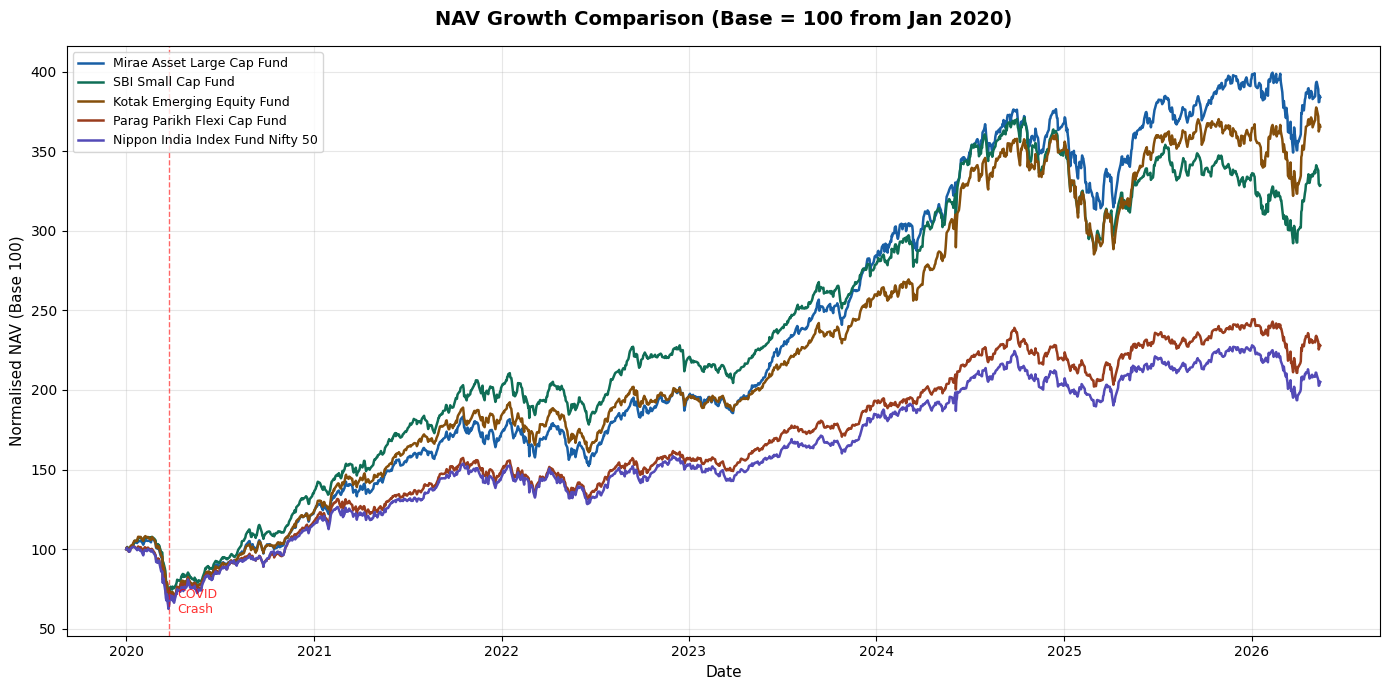

Chart saved to output folder!


In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fix - recalculate daily returns properly, drop NaN and zero-nav rows
def clean_fund(df):
    df = df.copy()
    df['nav'] = pd.to_numeric(df['nav'], errors='coerce')
    df = df.dropna(subset=['nav'])
    df = df[df['nav'] > 0]
    df = df.sort_values('date').reset_index(drop=True)
    return df

# Filter to 2020 onwards for clean comparison
start = pd.Timestamp('2020-01-01')

# Pick 5 interesting funds to plot
funds_to_plot = [
    'Mirae Asset Large Cap Fund',
    'SBI Small Cap Fund',
    'Kotak Emerging Equity Fund',
    'Parag Parikh Flexi Cap Fund',
    'Nippon India Index Fund Nifty 50'
]

colors = ['#185FA5', '#0F6E56', '#854F0B', '#993C1D', '#534AB7']

fig, ax = plt.subplots(figsize=(14, 7))

for i, fund_name in enumerate(funds_to_plot):
    fund_data = master_df[master_df['fund_name'] == fund_name].copy()
    fund_data = clean_fund(fund_data)
    fund_data = fund_data[fund_data['date'] >= start]
    
    if len(fund_data) == 0:
        continue
    
    # Normalise to 100 at start — so all funds start at same point
    # This makes growth comparison fair regardless of NAV price
    base_nav = fund_data['nav'].iloc[0]
    fund_data['normalised'] = (fund_data['nav'] / base_nav) * 100
    
    ax.plot(fund_data['date'], 
            fund_data['normalised'], 
            label=fund_name, 
            color=colors[i], 
            linewidth=1.8)

# Mark COVID crash
ax.axvline(pd.Timestamp('2020-03-24'), color='red', 
           linestyle='--', linewidth=1, alpha=0.6)
ax.text(pd.Timestamp('2020-04-10'), 60, 'COVID\nCrash', 
        fontsize=9, color='red', alpha=0.8)

ax.set_title('NAV Growth Comparison (Base = 100 from Jan 2020)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Normalised NAV (Base 100)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../output/nav_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to output folder!")

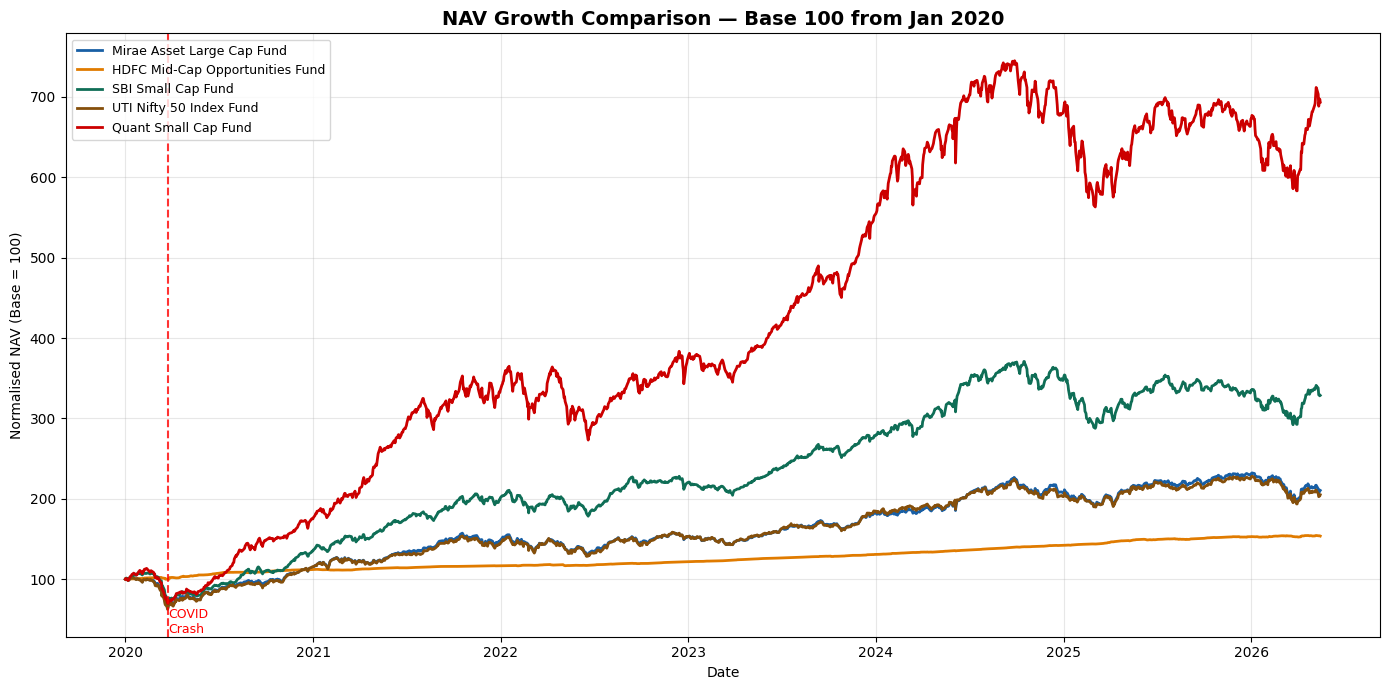

✅ Chart saved to output/nav_comparison_chart.png


In [31]:
# ============================================================
# CELL 12 — NAV Growth Comparison Chart (5 representative funds)
# ============================================================
# We pick 5 funds from our verified list — one from each
# category plus the star performer — to show on one chart.
# We normalise all NAVs to base 100 from Jan 2020 so we can
# compare them fairly (like a race starting at the same point).
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# These 5 funds are all in our verified 35-fund list
# One from each category + the overall best performer
funds_to_plot = [
    'Mirae Asset Large Cap Fund',      # Large Cap representative
    'HDFC Mid-Cap Opportunities Fund', # Mid Cap representative
    'SBI Small Cap Fund',              # Small Cap representative
    'UTI Nifty 50 Index Fund',         # Index Fund representative
    'Quant Small Cap Fund',            # Best performer overall
]

# Filter master_df to only these 5 funds, from Jan 2020 onwards
# This is like: SELECT * FROM master_df WHERE date >= '2020-01-01' AND fund_name IN (...)
start = pd.Timestamp('2020-01-01')
plot_data = master_df[
    (master_df['date'] >= start) &
    (master_df['fund_name'].isin(funds_to_plot))
].copy()

# Normalise to base 100: divide each fund's NAV by its first NAV, multiply by 100
# This means: on Day 1, all funds start at 100. A value of 150 = 50% growth.
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#185FA5', '#E07B00', '#0F6E56', '#854F0B', '#CC0000']

for i, fund_name in enumerate(funds_to_plot):
    fund_df = plot_data[plot_data['fund_name'] == fund_name].sort_values('date')
    if fund_df.empty:
        print(f"⚠️  No data found for: {fund_name}")
        continue
    first_nav = fund_df['nav'].iloc[0]
    normalised = (fund_df['nav'] / first_nav) * 100
    ax.plot(fund_df['date'], normalised, label=fund_name, color=colors[i], linewidth=2)

# Mark the COVID crash with a red dotted line
ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle='--',
           linewidth=1.5, alpha=0.8)
ax.text(pd.Timestamp('2020-03-25'), ax.get_ylim()[0] + 5,
        'COVID\nCrash', color='red', fontsize=9)

ax.set_title('NAV Growth Comparison — Base 100 from Jan 2020',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised NAV (Base = 100)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../output/nav_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to output/nav_comparison_chart.png")